In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

sns.set_style('whitegrid')



In [28]:
conn = sqlite3.connect('../Data/Cleaned/bankruptcy.db')

df = pd.read_sql_query('SELECT * FROM financials', conn)

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78682 entries, 0 to 78681
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   company_id              78682 non-null  int64  
 1   year                    78682 non-null  int64  
 2   status_label            78682 non-null  object 
 3   bankrupt                78682 non-null  int64  
 4   ebitda                  78682 non-null  float64
 5   net_income              78682 non-null  float64
 6   log_market_value        78682 non-null  float64
 7   long_term_debt          78682 non-null  float64
 8   retained_earnings       78682 non-null  float64
 9   total_revenue           78682 non-null  float64
 10  current_ratio           78682 non-null  float64
 11  debt_ratio              78682 non-null  float64
 12  net_profit_margin       78682 non-null  float64
 13  asset_turnover_ratio    78682 non-null  float64
 14  inventory_turnover      78682 non-null

In [29]:
print(df['bankrupt'].value_counts())

df.groupby('bankrupt').mean(numeric_only = True)

bankrupt
0    73462
1     5220
Name: count, dtype: int64


,company_id,year,ebitda,net_income,log_market_value,long_term_debt,retained_earnings,total_revenue,current_ratio,debt_ratio,net_profit_margin,asset_turnover_ratio,inventory_turnover,interest_rate_pressure
bankrupt,,,,,,,,,,,,,,
0,4077.926288,2007.633892,393.684586,141.994726,5.451827,730.516984,582.034710,2447.871581,3.566022,1.961866,-11.517297,1.178438,24.641613,2.801208
1,4120.169732,2005.710920,138.568576,-48.112333,4.774831,609.430007,-165.107267,1183.957172,2.444478,1.381208,-11.007313,1.166898,24.470430,3.342472


bankrupt
0    6324.000000
1    1302.466667
Name: debt_ratio, dtype: float64
bankrupt
0    1.961866
1    1.381208
Name: debt_ratio, dtype: float64
bankrupt
0    0.500000
1    0.628067
Name: debt_ratio, dtype: float64
Axes(0.125,0.11;0.775x0.77)


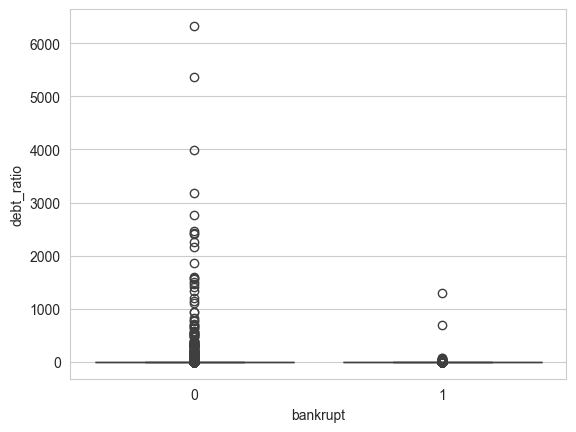

In [30]:
print(df.groupby('bankrupt')['debt_ratio'].max())
print(df.groupby('bankrupt')['debt_ratio'].mean())
print(df.groupby('bankrupt')['debt_ratio'].median())
print(sns.boxplot(x='bankrupt', y='debt_ratio', data=df))

<Axes: >

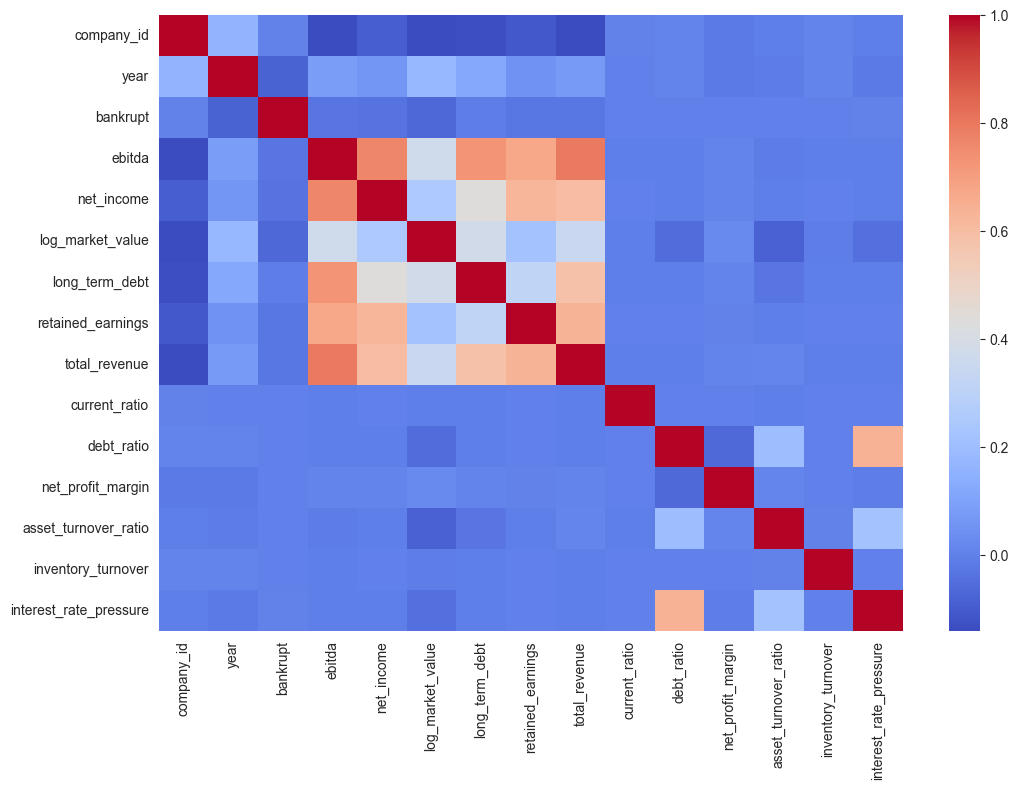

In [34]:
plt.figure(figsize=(12,8))
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), cmap='coolwarm')

In [35]:
df.corr(numeric_only=True)['bankrupt'].sort_values(ascending=False)

bankrupt                  1.000000
company_id                0.004047
interest_rate_pressure    0.001899
net_profit_margin         0.000454
inventory_turnover       -0.000104
asset_turnover_ratio     -0.000886
debt_ratio               -0.003112
current_ratio            -0.003145
long_term_debt           -0.009295
total_revenue            -0.026323
retained_earnings        -0.029195
ebitda                   -0.031557
net_income               -0.037387
log_market_value         -0.069362
year                     -0.083339
Name: bankrupt, dtype: float64

In [46]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report



In [53]:
model = LogisticRegression(class_weight='balanced')
features = [
    'log_market_value',
    'net_income',
    'ebitda',
    'debt_ratio',
    'current_ratio',
    'net_profit_margin',
    'interest_rate_pressure'
]

x = df[features]
y = df['bankrupt']

x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

model.fit(x_train_scaled, y_train)

y_pred = model.predict(x_test_scaled)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.95      0.55      0.70     14693
           1       0.09      0.63      0.16      1044

    accuracy                           0.56     15737
   macro avg       0.52      0.59      0.43     15737
weighted avg       0.90      0.56      0.66     15737



### Logistic Regression

Logistic Regression improves recall for bankruptcy prediction but precision is very low which means there is quite a few false positives

In [65]:
rf = RandomForestClassifier(class_weight='balanced', random_state=42)

rf.fit(x_train, y_train)
y_pred_rf = rf.predict(x_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.93      1.00      0.97     14693
           1       0.68      0.01      0.02      1044

    accuracy                           0.93     15737
   macro avg       0.81      0.51      0.50     15737
weighted avg       0.92      0.93      0.90     15737



### Random Forest

Random forest achievese higher accuracy than logistic regression but has lower recall, meaning it fails to detect some bankrupt companies. This shows the impact of class imbalances.

In [66]:
y_probs = rf.predict_proba(x_test)[:, 1]

y_pred_rf = (y_probs > 0.2).astype(int)

print(classification_report(y_test, y_pred_rf))


              precision    recall  f1-score   support

           0       0.94      0.96      0.95     14693
           1       0.26      0.20      0.23      1044

    accuracy                           0.91     15737
   macro avg       0.60      0.58      0.59     15737
weighted avg       0.90      0.91      0.90     15737



### Random Forest (0.2 Threshold)

Lowering the threshold from 0.5 default to 0.2 increased recall and helped identify at risk companies.

In [67]:
importances = rf.feature_importances_
feat_importance = pd.Series(importances, index=features).sort_values(ascending=False)

print(feat_importance)

net_income                0.152925
net_profit_margin         0.147447
log_market_value          0.146774
debt_ratio                0.144410
interest_rate_pressure    0.141973
ebitda                    0.136243
current_ratio             0.130228
dtype: float64


In [68]:
# add engineered features to see if there is stronger correlation
df['debt_to_income'] = df['long_term_debt'] / (df['net_income'] + 1)
df['debt_to_ebitda'] = df['long_term_debt'] / (df['ebitda'] + 1)
df['negative_income'] = (df['net_income'] < 0).astype(int)
df['low_liquidity'] = (df['current_ratio'] < 1).astype(int)
df['high_debt'] = (df['debt_ratio'] > 0.6).astype(int)

features_model_2 = [
    'log_market_value',
    'net_income',
    'debt_ratio',
    'current_ratio',
    'net_profit_margin',
    'interest_rate_pressure',
    'debt_to_income',
    'debt_to_ebitda',
    'negative_income',
    'low_liquidity',
    'high_debt'
]

### Feature Engineering

added additonal features to find stronger correlations

In [69]:
model_df = df[features_model_2 + ['bankrupt']].replace([np.inf, -np.inf], np.nan).dropna()
x_v2 = model_df[features_model_2]
y_v2 = model_df['bankrupt']

x_train_v2, x_test_v2, y_train_v2, y_test_v2 = train_test_split(
    x_v2, y_v2, test_size=0.2, stratify=y_v2, random_state=42
)

rf_v2 = RandomForestClassifier(class_weight='balanced', random_state=42)
rf_v2.fit(x_train_v2, y_train_v2)

y_pred_v2 = rf_v2.predict(x_test_v2)
print("Random Forest V2 Results:")
print(classification_report(y_test_v2, y_pred_v2))

y_probs_v2 = rf_v2.predict_proba(x_test_v2)[:, 1]

y_pred_v2_02 = (y_probs_v2 > 0.2).astype(int)

print("Random Forest V2 (Threshold 0.2):")
print(classification_report(y_test_v2, y_pred_v2_02))



Random Forest V2 Results:
              precision    recall  f1-score   support

           0       0.93      1.00      0.97     14691
           1       0.62      0.01      0.02      1044

    accuracy                           0.93     15735
   macro avg       0.77      0.50      0.49     15735
weighted avg       0.91      0.93      0.90     15735

Random Forest V2 (Threshold 0.2):
              precision    recall  f1-score   support

           0       0.94      0.96      0.95     14691
           1       0.26      0.18      0.21      1044

    accuracy                           0.91     15735
   macro avg       0.60      0.57      0.58     15735
weighted avg       0.90      0.91      0.90     15735



### Random Forest V2

Additional engineered features did not significantly change model